<a href="https://colab.research.google.com/github/vuhamodala/Float-Chat-for-Indian-ocean-Data/blob/main/GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("arabian_sea_8features.csv",
                 parse_dates=['time'],
                 index_col='time')

df = df.sort_index()

print(df.head())

            temp_mean  temp_std   sal_mean   sal_std  day_of_year  month  \
time                                                                       
2019-01-04   6.228830  0.022486  35.041953  0.001571            4      1   
2019-01-05   5.902127  0.019325  35.031970  0.001417            5      1   
2019-01-06   5.575425  0.016164  35.021987  0.001264            6      1   
2019-01-07   5.248723  0.013003  35.012004  0.001110            7      1   
2019-01-08   4.922021  0.009842  35.002021  0.000956            8      1   

            temp_trend  sal_trend  
time                               
2019-01-04   -0.326702  -0.009983  
2019-01-05   -0.326702  -0.009983  
2019-01-06   -0.326702  -0.009983  
2019-01-07   -0.326702  -0.009983  
2019-01-08   -0.326702  -0.009983  


In [2]:
df['day_of_year'] = df['day_of_year'] / 365.0
df['month'] = df['month'] / 12.0

In [3]:
features = [
    'temp_mean',
    'temp_std',
    'sal_mean',
    'sal_std',
    'day_of_year',
    'month',
    'temp_trend',
    'sal_trend'
]

df = df[features]

In [4]:
split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df = df.iloc[split:]

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

In [6]:
import numpy as np

def create_sequences(data, seq_len=40, horizon=7):
    X, y = [], []

    for i in range(len(data) - seq_len - horizon):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+horizon, 0])  # temp_mean

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1410, 40, 8)
y_train shape: (1410, 7)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

model = Sequential()

model.add(GRU(96, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.15))

model.add(GRU(64, return_sequences=True))
model.add(Dropout(0.15))

model.add(GRU(32))
model.add(Dropout(0.1))

model.add(Dense(7))

model.compile(optimizer='adam', loss='mae')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 40, 96)         │        30,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 40, 64)         │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,271 (278.40 KB)

 Trainable params: 71,271 (278.40 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - loss: 0.1007 - val_loss: 0.0652
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0594 - val_loss: 0.0603
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0536 - val_loss: 0.0494
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0507 - val_loss: 0.0470
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0486 - val_loss: 0.0470
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0462 - val_loss: 0.0492
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0463 - val_loss: 0.0471
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 0.0454 - val_loss: 0.0480
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0440 - val_loss: 0.0477


In [9]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [10]:
temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

train_pred_rescaled = train_pred * (temp_max - temp_min) + temp_min
y_train_rescaled = y_train * (temp_max - temp_min) + temp_min
test_pred_rescaled = test_pred * (temp_max - temp_min) + temp_min
y_test_rescaled = y_test * (temp_max - temp_min) + temp_min

In [11]:
y_train_true = y_train_rescaled.flatten()
y_train_pred = train_pred_rescaled.flatten()

y_test_true = y_test_rescaled.flatten()
y_test_pred = test_pred_rescaled.flatten()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

train_mae, train_rmse, train_mape = evaluate(y_train_true, y_train_pred)
test_mae, test_rmse, test_mape = evaluate(y_test_true, y_test_pred)

print(" GRU MODEL RESULTS\n")

print("TRAIN:")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAPE : {train_mape:.2f}%")

print("\nTEST:")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAPE : {test_mape:.2f}%")

 GRU MODEL RESULTS

TRAIN:
MAE  : 0.4425
RMSE : 0.6458
MAPE : 5.74%

TEST:
MAE  : 0.5375
RMSE : 0.7111
MAPE : 7.09%


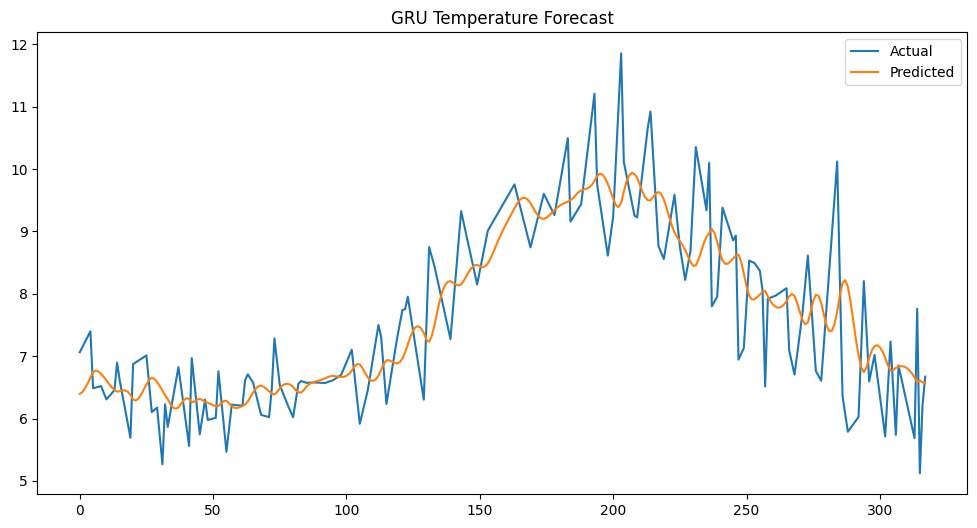

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_rescaled[:, 0], label="Actual")
plt.plot(test_pred_rescaled[:, 0], label="Predicted")

plt.title("GRU Temperature Forecast")
plt.legend()

plt.show()